In [1]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
print("Please upload a test image containing a face:")
uploaded = files.upload()
filename = next(iter(uploaded))
print(f"Successfully loaded: {filename}")

Please upload a test image containing a face:


Saving kiara.jpg to kiara.jpg
Successfully loaded: kiara.jpg


In [2]:
image = cv2.imread(filename)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

Image prepped and models loaded successfully!


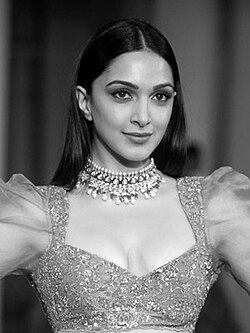

In [3]:
print("Image prepped and models loaded successfully!")
cv2_imshow(gray_image)

Detection complete! Found 1 face(s).


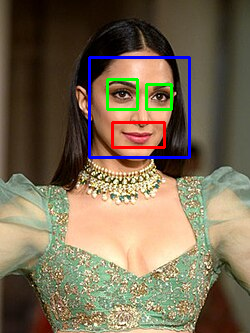

In [6]:
faces = face_cascade.detectMultiScale(
    gray_image,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print(f"Detection complete! Found {len(faces)} face(s).")

for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)

    roi_gray = gray_image[y:y+h, x:x+w]
    roi_color = image[y:y+h, x:x+w]

    half_height = int(h / 2)

    top_half_gray = roi_gray[0:int(h * 0.65), 0:w]
    top_half_color = roi_color[0:int(h * 0.65), 0:w]

    bottom_half_gray = roi_gray[half_height:h, 0:w]
    bottom_half_color = roi_color[half_height:h, 0:w]

    top_half_gray = cv2.equalizeHist(top_half_gray)

    eyes = eye_cascade.detectMultiScale(
        top_half_gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(15, 15)
    )

    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(top_half_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

    smiles = smile_cascade.detectMultiScale(
        bottom_half_gray,
        scaleFactor=1.3,
        minNeighbors=10
    )

    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(bottom_half_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)

cv2_imshow(image)